In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az
from pytensor import scan

In [2]:
START_SEASON = 2011
END_SEASON = 2015
TEST_SEASON = 2016

data = pd.read_csv("sample.csv")
data = data[(data["season"] >= START_SEASON) & (data["season"] <= TEST_SEASON)]
teams = sorted(data["home_team"].unique())
team_to_idx = {team: i for i, team in enumerate(teams)}
data["home_idx"] = data["home_team"].map(team_to_idx)
data["away_idx"] = data["away_team"].map(team_to_idx)
seasons = sorted(data["season"].unique())
season_to_idx = {season: i for i, season in enumerate(seasons)}
data["season_idx"] = data["season"].map(season_to_idx)
weeks = sorted(data["week"].unique())
week_to_idx = {week: i for i, week in enumerate(weeks)}
data["week_idx"] = data["week"].map(week_to_idx)
data = data[["season", "week", "season_idx", "week_idx", "home_idx", "away_idx", "result"]]

train_data = data[data["season"] < TEST_SEASON]
test_data = data[data["season"] == TEST_SEASON]

p = int(data["home_idx"].max() + 1)
num_weeks = int(data["week_idx"].max() + 1)
num_seasons_train = int(data["season_idx"].max())
num_seasons_test = int(data["season_idx"].max() + 1)

In [3]:
def build_design_matrix(week):
    X = np.zeros((len(week), 64))
    for i, row in enumerate(week.itertuples()):
        home = int(row.home_idx)
        away = int(row.away_idx)
        X[i, home] = 1
        X[i, away] = -1
        X[i, 32 + home] = 1
    return X

p = 32
num_weeks = data["week_idx"].max() + 1
num_seasons = data["season_idx"].max() + 1

week_data = []
for season in range(num_seasons_train):
    sub_df = train_data[train_data["season_idx"] == season]
    for week in range(num_weeks):
        week_data.append(sub_df[sub_df["week_idx"] == week])

y_obs = [week_data[i]["result"].values for i in range(len(week_data))]
x_mats = [build_design_matrix(week_data[i]) for i in range(len(week_data))]

In [ ]:
with pm.Model() as model:
    # ---------------------------------------------------
    # Priors
    # ---------------------------------------------------
    phi = pm.Gamma("phi", alpha=0.5, beta=0.5 * 100)
    omega_s = pm.Gamma("omega_s", alpha=0.5, beta=0.5 / 16)
    omega_w = pm.Gamma("omega_w", alpha=0.5, beta=0.5 / 60)
    beta_s = pm.Normal("beta_s", mu=0.98, sigma=1)
    beta_w = pm.Normal("beta_w", mu=0.995, sigma=1)
    omega_h = pm.Gamma("omega_h", alpha=0.5, beta=0.5 / 6)
    omega_zero = pm.Gamma("omega_0", alpha=0.5, beta=0.5 / 6)

    alpha = pm.Normal("alpha", mu=3, sigma=1 / pt.sqrt(omega_h * phi), shape=p)

    # ---------------------------------------------------
    # Initial state
    # ---------------------------------------------------
    mu_init = pm.Normal("mu_init", mu=0, sigma=1 / pt.sqrt(omega_zero * phi), shape=p)

    # ---------------------------------------------------
    # Random innovations for each time step
    # Flatten seasons x weeks
    num_steps = num_seasons * num_weeks
    eps = pm.Normal("eps", mu=0, sigma=1, shape=(num_steps, p))

    # ---------------------------------------------------
    # Scan step function
    # ---------------------------------------------------
    def step(prev_mu, eps_t, season_idx, phi, omega_s, omega_w, beta_s, beta_w):
        prev_mu_centered = prev_mu - pt.mean(prev_mu)
        beta = pt.switch(pt.eq(season_idx, 0), beta_s, beta_w)
        omega = pt.switch(pt.eq(season_idx, 0), omega_s, omega_w)
        sigma = 1 / pt.sqrt(phi * omega)
        mu_t = beta * prev_mu_centered + sigma * eps_t
        return mu_t

    # Sequence of season indices
    season_idx_seq = pt.repeat(pt.arange(num_seasons), num_weeks)

    # Run scan
    mu_evol, _ = scan(
        fn=step,
        sequences=[eps, season_idx_seq],
        outputs_info=mu_init,
        non_sequences=[phi, omega_s, omega_w, beta_s, beta_w])

    # Reshape back to (num_seasons, num_weeks, p)
    mu_evol = mu_evol.reshape((num_seasons, num_weeks, p))
    pm.Deterministic("theta", mu_evol)

    # ---------------------------------------------------
    # Likelihood
    # ---------------------------------------------------
    for i, (x, y) in enumerate(zip(x_mats, y_obs)):
        s_idx = int(data.iloc[i]["season_idx"])
        w_idx = int(data.iloc[i]["week_idx"])
        theta_week = mu_evol[s_idx, w_idx, :]
        theta_vec = pt.concatenate([theta_week, alpha])
        mu = pt.dot(x, theta_vec)
        pm.Normal(f"y_{i}", mu=mu, sigma=1 / pt.sqrt(phi), observed=y)


In [5]:
initvals = [
    {
        "omega_w": 10.0,
        "omega_s": 1.0,
        "omega_0": 0.5,
        "omega_h": 100.0,
        "beta_w": 0.6,
        "beta_s": 0.5,
    },
    {
        "omega_w": 100.0,
        "omega_s": 20.0,
        "omega_0": 5.0,
        "omega_h": 20.0,
        "beta_w": 0.8,
        "beta_s": 0.8,
    },
    {
        "omega_w": 200.0,
        "omega_s": 80.0,
        "omega_0": 15.0,
        "omega_h": 6.0,
        "beta_w": 0.99,
        "beta_s": 0.98,
    },
    {
        "omega_w": 500.0,
        "omega_s": 200.0,
        "omega_0": 100.0,
        "omega_h": 1.0,
        "beta_w": 1.2,
        "beta_s": 1.2,
    },
    {
        "omega_w": 1000.0,
        "omega_s": 800.0,
        "omega_0": 150.0,
        "omega_h": 0.6,
        "beta_w": 1.8,
        "beta_s": 1.8,
    },
    {
        "omega_w": 1000.0,
        "omega_s": 1.0,
        "omega_0": 150.0,
        "omega_h": 0.3,
        "beta_w": 0.6,
        "beta_s": 1.8,
    },
    {
        "omega_w": 10.0,
        "omega_s": 800.0,
        "omega_0": 0.5,
        "omega_h": 100.0,
        "beta_w": 1.8,
        "beta_s": 0.6,
    },
]

In [6]:
with model:
    trace = pm.sample(
        draws=1000,#1000,
        tune=2000,#17000,
        chains=7,
        cores=7,
        initvals=initvals,
        target_accept=0.95,
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (7 chains in 7 jobs)
NUTS: [phi, omega_s, omega_w, beta_s, beta_w, omega_h, omega_0, alpha, mu_init, eps]


Output()

Sampling 7 chains for 2_000 tune and 1_000 draw iterations (14_000 + 7_000 draws total) took 1592 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


<Axes: >

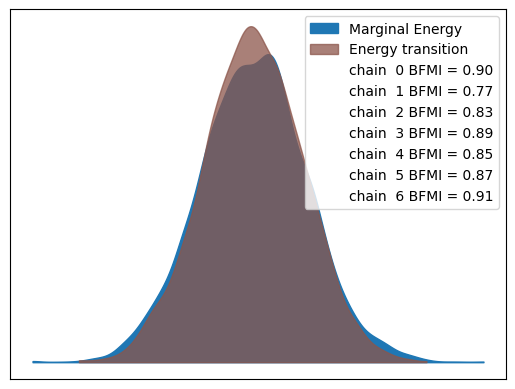

In [7]:
az.plot_energy(trace)

In [8]:
trace.sample_stats.diverging.sum().values

array(0)

In [9]:
az.summary(trace, var_names=["omega_w", "omega_s", "omega_0", "omega_h", "beta_w", "beta_s", "alpha"], round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
omega_w,60.30,84.39,0.00,209.65,0.86,2.00,5636.01,2891.54,1.00
omega_s,16.40,23.59,0.00,57.99,0.25,0.65,4373.02,2188.75,1.00
omega_0,8.03,9.27,0.03,23.97,0.62,0.51,109.34,83.60,1.06
omega_h,18.01,7.20,7.34,31.42,0.14,0.14,2770.29,4645.71,1.00
beta_w,0.69,4.00,-4.39,4.76,1.50,0.22,11.07,135.36,1.69
beta_s,0.98,1.00,-0.92,2.79,0.01,0.01,9767.98,5168.02,1.00
alpha[0],3.47,1.92,-0.22,7.01,0.02,0.02,6044.55,4927.16,1.00
alpha[1],4.23,1.96,0.71,8.01,0.02,0.02,8071.04,5511.83,1.00
alpha[2],4.17,1.87,0.67,7.64,0.02,0.02,7584.60,5967.44,1.00
alpha[3],1.18,1.94,-2.42,4.76,0.02,0.02,6709.96,5351.30,1.00


In [10]:
trace.posterior["theta"].values.mean(axis=(0, 1)).mean()

np.float64(7.099975369533647e-17)